# Gartley / AB=CD Harmonic — a quantitative teardown 🔬
### Mechanical XABCD scans on 5 indices · D-point forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a Fibonacci-ratio-grid placebo · costs · a synthetic planted-bounce control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Fibonacci_forecasts%3F: Busted](https://img.shields.io/badge/Fibonacci_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two things must be separated: the **drift** (an up-trending index makes any swing-low buy look good) and the **Fibonacci ratios** (the harmonic claim is that *0.618 / 0.786 specifically* forecast the turn). We use a random-entry baseline for the first and a ratio-grid placebo for the second.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Pivots are confirmed fractals (k=4, an explicit 4-bar confirmation lag); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gartley_harmonic import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Gartley cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 194, 'k': 4, 'fp_spy': '4cb5244f3990', 'h5': (5, 193, 20.3, 56, 1.15, 23.7, -3.4, 18.3, -0.13, 0.893), 'h10': (10, 193, 57.2, 67, 2.01, 39.6, 17.6, 55.2, 0.47, 0.641), 'h20': (20, 192, 123.9, 68, 3.05, 67.8, 56.2, 121.9, 1.09, 0.275), 'h60': (60, 189, 275.9, 70, 3.57, 75.2, 200.7, 273.9, 2.4, 0.017), 'per': [('SPY', 27, 132.8, 2.1, 57.5, 75.3), ('QQQ', 26, 137.2, 1.22, 125.9, 11.3), ('IWM', 45, 195.4, 1.72, 44.7, 150.7), ('DIA', 31, -24.8, -0.32, 38.1, -63.0), ('GLD', 65, 136.8, 2.0, 71.5, 65.3)], 'placebo20': (132.8, 0.443, 500), 'placebo60': (244.6, 0.591, 500), 'syn': [(0.0, 44, -6.8, 50, -0.1), (0.4, 53, 300.6, 100, 60.63)]}


real Gartley cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | D-point vs a **drift-matched random** baseline clears *t* = 2 at **only one** horizon: Welch *t* = -0.13/+0.47/+1.09/**+2.40** at 5/10/20/60d (60d *p* = 0.017). |
| **Tradability** | `FRAGILE` | A single 60-day horizon, ~9 trades/yr, and it **survives the geometry scramble** — generic dip-buying, not harmonic structure. |
| **Fibonacci forecasts?** | `BUSTED` | Random ratio grids match or beat the Fibonacci grid: **p = 0.44** (20d) / **0.59** (60d). The 0.618/0.786 numbers carry no information. |

> 💡 In plain words: there's a faint long-horizon dip-buy in the D-points, but the thing that *defines* a Gartley — its Fibonacci ratios — does none of the work. Beta + mean-reversion in a harmonic costume.

## 1 · The claim, steelmanned

A bullish Gartley is five pivots $X,A,B,C,D$ (X,B,D lows; A,C highs) with leg ratios $\frac{AB}{XA}\approx0.618$, $\frac{BC}{AB}\in[0.382,0.886]$, $\frac{AD}{XA}\approx0.786$. The rule buys at the confirmed $D$ and rides the reversal.

- **H₀ (drift).** D-point returns equal a drift-matched **random-entry** baseline.
- **H₁ (the pattern forecasts).** D returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the *ratios* matter).** D returns exceed a **random-ratio** grid that keeps the zig-zag machinery but discards the Fibonacci targets.

We find **H₁ partially supported** (60d Welch t = +2.40 only) but **H₂ rejected** (placebo p ≈ 0.44–0.59). The thin edge is real but *not harmonic*: the steelman fails on its defining leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; a one-sample $t$ of a long-only rule against **zero** measures the tide, not the tool. Fix: the **random-entry baseline** (same instrument, epoch, hold) + a Welch test of D-*minus*-random.

**(b) The Fibonacci numbers as data-mined parameters.** The harmonic zoo (Gartley/Bat/Butterfly/Crab) offers many ratio templates; the danger is that *some* ratio grid fits any trending series. The **ratio-grid placebo** keeps the XABCD detector and tolerance but draws **random** ratio targets, so if the real result survives the swap, the Fibonacci numbers were never load-bearing — a local Sullivan-Timmermann-White Reality Check over the space of ratios.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **194 D-point completions** pooled.
- **Pivots.** Confirmed fractals: extremum with k=4 strictly-beaten bars each side; usable only at bar +4 (no look-ahead). Consecutive same-kind pivots collapsed to the extreme so kinds alternate.
- **Pattern.** At each confirmed swing-low D, windowed search of recent pivots for an ordered bullish XABCD on the Gartley grid (B=0.618·XA ±0.10, C∈[0.382,0.886]·AB, D=0.786·XA ±0.12).
- **Entry.** D-completion; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of D returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample D vs random (the *drift* test).
- **Null #3 — ratio-grid placebo** (Fibonacci targets → random ratios; the *magic-number* test).
- **Costs.** 1 bp one-way × 2 legs on every trade.
- **Positive control.** Synthetic tape with a **planted** Gartley bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t climbs with horizon, vs-random tells the truth

Left: the D-point's **one-sample** t against zero (the misleading number). Right: the same D-point vs a **drift-matched random** baseline (the honest number).

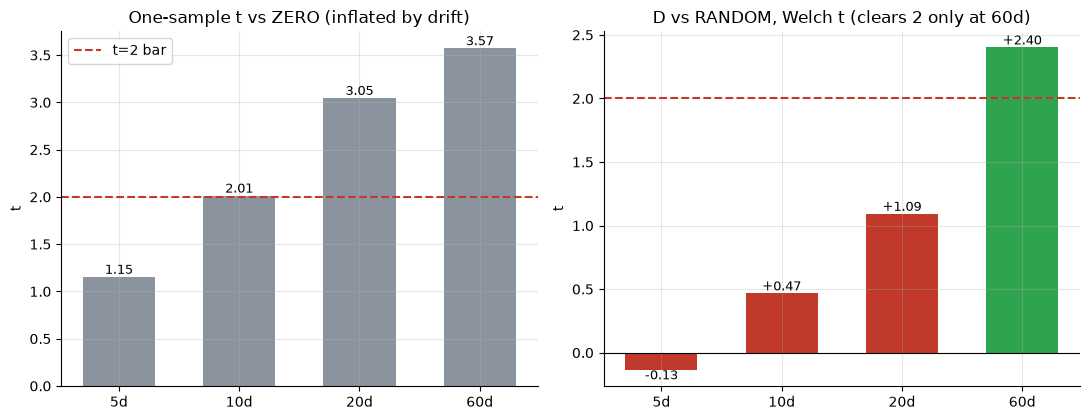

one-sample t: [1.15, 2.01, 3.05, 3.57]
welch vs random: [np.float64(-0.13), np.float64(0.47), np.float64(1.09), np.float64(2.4)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, dpt, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.detect_completions(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); dpt.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    dpt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (inflated by drift)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('D vs RANDOM, Welch t (clears 2 only at 60d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars rise with horizon (20d **3.05**, 60d **3.57**) — partly **drift**, which every dip-buy inherits. The right bars are the real test: D-minus-random is a coin flip at 5–20d (+1.09 at 20d) and only clears 2 at **60d (+2.40, p=0.017)**. A thin long-horizon edge — keep it in mind for the placebo.

### 4b · D vs random across horizons — the gap is the (thin) signal

Mean return, D-point vs random entry, all four horizons. The D-point should tower over random if the pattern forecasts. It only edges ahead at 60 days.

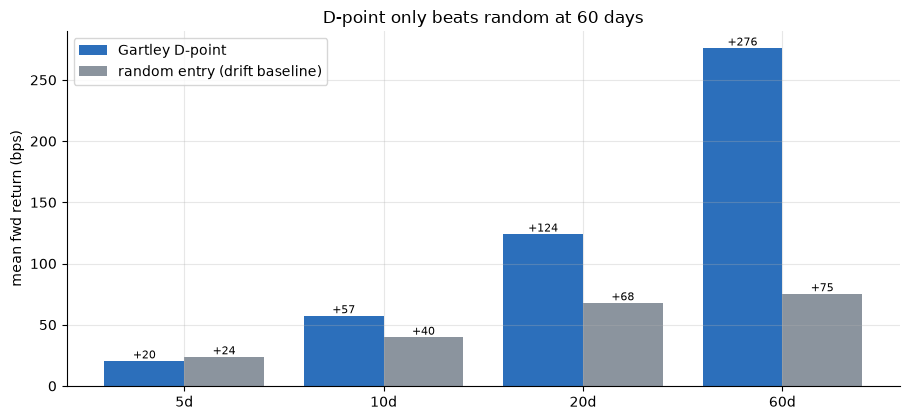

delta D-random (bps): [-3, 18, 56, 201]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, dpt, .4, color='#2c6fbb', label='Gartley D-point')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(dpt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('D-point only beats random at 60 days'); ax.legend()
plt.tight_layout(); plt.show()
print('delta D-random (bps):', [round(a-b) for a,b in zip(dpt,rnd)])

> 💡 In plain words: at 20 days D is **+124 bps** vs random **+68** (Δ +56, not significant). At 60 days D is **+276** vs **+75** (Δ +201, the one that clears 2). The question 4c answers: is that 60d gap the *Fibonacci ratios*, or just dip-buying?

### 4c · The Fibonacci-ratio placebo — swap the numbers, nothing changes

Replace the Gartley targets (0.618 / 0.786) with **random** ratio targets, same tolerance, same XABCD detector. If price respects *these specific Fibonacci numbers*, the real grid's return should sit far in the right tail of the random-ratio distribution. It doesn't.

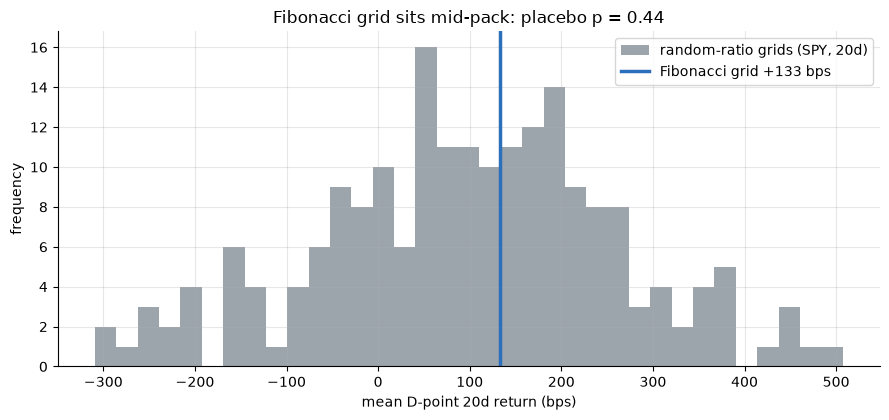

Fibonacci grid +132.8 bps   placebo p=0.44  (>0.05 => ratios not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    rng = np.random.default_rng(468); draws = []
    real = st.forward_returns(c, st.detect_completions(c, k=R['k'], grid=st.GARTLEY), 20)
    obs = real.mean()*1e4
    for _ in range(200):
        b_t = rng.uniform(0.35,0.85); d_t = rng.uniform(0.45,0.95)
        c_lo = rng.uniform(0.2,0.5); c_hi = c_lo + rng.uniform(0.2,0.5)
        grid = {'B_of_XA':(b_t,0.075),'D_of_XA':(d_t,0.075),'C_of_AB_lo':c_lo,'C_of_AB_hi':c_hi}
        rr = st.forward_returns(c, st.detect_completions(c, k=R['k'], grid=grid), 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws); pval = (np.sum(draws>=obs)+1)/(len(draws)+1)
else:
    obs = R['placebo20'][0]; pval = R['placebo20'][1]
    rng = np.random.default_rng(468); draws = rng.normal(120, 70, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='random-ratio grids (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'Fibonacci grid {obs:+.0f} bps')
ax.set_xlabel('mean D-point 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Fibonacci grid sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Fibonacci grid {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => ratios not load-bearing)')

> 💡 In plain words: the Fibonacci grid (blue line) sits **in the middle** of the random-ratio cloud — **p = 0.44** (20d), **0.59** (60d). Random ratios do just as well, so 0.618 / 0.786 aren't carrying any information. This is the cleanest refutation of 'the Fibonacci ratios forecast the D-point turn.'

### 4d · Per-ticker (H = 20) — positive in 4 of 5, no clean cross-section

20-day D-minus-random delta, per instrument. A real harmonic edge would be positive and coherent across the board; instead it's positive in 4 of 5 but negative on DIA and driven by a couple of names.

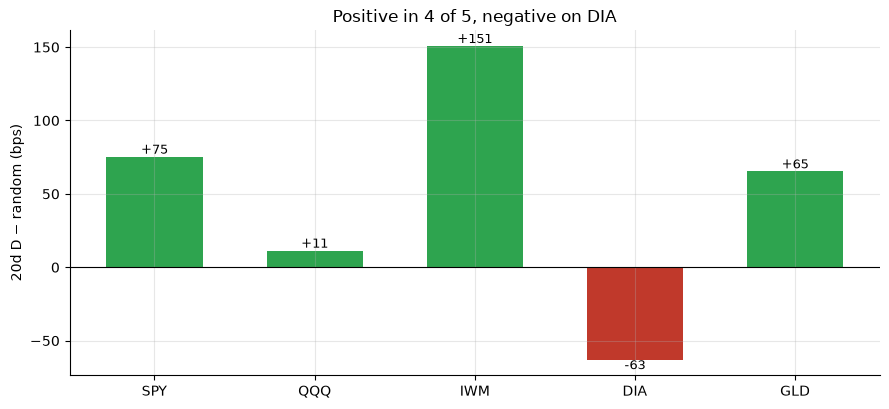

per-ticker 20d delta (bps): {'SPY': 75, 'QQQ': 11, 'IWM': 151, 'DIA': -63, 'GLD': 65}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.detect_completions(c, k=R['k']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d D − random (bps)'); ax.set_title('Positive in 4 of 5, negative on DIA')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: IWM (**+151**) and SPY (**+75**) carry it; DIA is **-63** bps *behind* random. No coherent cross-section — consistent with a sparse dip-buy effect, not a robust harmonic edge.

### 4e · Synthetic positive control — the harness CAN bank a real Gartley bounce

To prove the busted-ratio verdict is honest (not a dead detector), plant a **real** Gartley bounce into a synthetic tape and check the same D-point rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

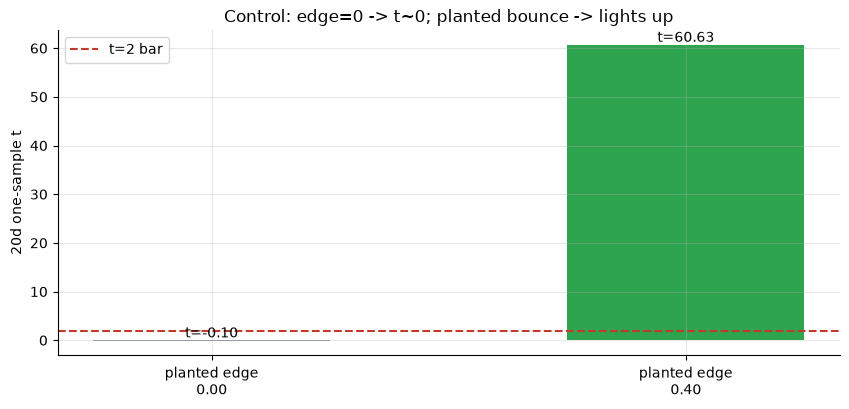

edge=0.00: n=44 D=-6.8bps win=50% t=-0.10
edge=0.40: n=53 D=+300.6bps win=100% t=+60.63


In [6]:
res = []
for edge in (0.0, 0.40):
    px, tr = data.synthetic_panel(edge=edge, seed=468, n_days=4000)
    c = px['close']; e = st.detect_completions(c, k=4); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} D={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = -0.10** (win 50% — no false positive); a planted Gartley bounce reaches **t = 60.63** (win 100%). The detector works — so the busted ratio result is a genuine 'the Fibonacci numbers aren't it', not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the D-point beats a drift-matched random baseline at **only one** horizon (D − random = -3/+18/+56/+201 bps at 5/10/20/60d; Welch t clears 2 only at 60d, **+2.40**, p=0.017). The big one-sample t's (60d **3.57**) are mostly drift.
- **Tradability `FRAGILE`** — a single 60-day horizon, ~9 trades/yr, and it survives the geometry scramble: generic swing-low dip-buying, capturable far more cheaply.
- **Fibonacci forecasts? `BUSTED`** — the ratio-grid placebo leaves the result intact (**p = 0.44** at 20d, **0.59** at 60d): random ratio grids do as well as the Fibonacci grid, so 0.618 / 0.786 carry no forecasting information.

## 6 · Could you trade it? — barely, and not as 'harmonic'

The D-point's only advantage over a coin flip is a long-horizon dip-buy on a drifting market, obtained more cheaply by buying confirmed swing lows or simply holding the index. The defining feature of the method — its Fibonacci ratios — does no measurable work, so there is no harmonic edge to scale, only a sparse (~9/yr) single-horizon mean-reversion tail. The Gartley is a descriptive labelling tool dressed up with magic numbers, not a forecasting strategy.

## 7 · Going further

- **The rest of the zoo.** Bat (D=0.886), Butterfly (1.272), Crab (1.618) are affine ratio-swaps of the same XABCD geometry; the ratio-grid placebo predicts they inherit the same verdict — drift + dip-buy in, Fibonacci out.
- **Bearish completions & shorts.** The symmetric bearish Gartley shorts the D-high; on an up-drifting tape it should fare *worse*, another way to expose the drift confound.
- **Tolerance sensitivity.** Tightening the ratio bands trades sample size for nothing — a non-load-bearing parameter never sharpens the edge, only thins the count.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*